In [1]:
import pandas as pd
import numpy as np
import warnings
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [230]:
# The %run command executes the code in the specified notebook 
# and makes all variables, classes, and functions available.

print("Executing FeatureEngineer.ipynb...")
%run ./FeatureEngineer.ipynb

print("Executing Models.ipynb...")
%run ./Models.ipynb

print("Executing Strategy.ipynb...")
%run ./Strategy.ipynb

# The classes and functions (e.g., FinancialFeatureEngineer, lightgbm_train) 
# are now available in this notebook's namespace.
print("✓ Modules loaded.")

Executing FeatureEngineer.ipynb...
Executing Models.ipynb...
Executing Strategy.ipynb...
✓ Modules loaded.


In [143]:
df = pd.read_csv('all_stocks_adjusted.csv')
df['Date'] = pd.to_datetime(df['Date'])
print(f"Data loaded successfully. Shape: {df.shape}")

Data loaded successfully. Shape: (235192, 15)


In [144]:
# Initialize Engineer
engineer = FinancialFeatureEngineer(offset_days=20)

# 1. Generate Features (Normalized=False to prevent leakage at this stage)
print("\n--- Generating Features (Raw) ---")
df_features = engineer.fit_transform(df, normalize=False)


# 2. Get feature categories (optional analysis)
print("\n--- Feature Categories ---")
categories = engineer.get_feature_categories(df_features)


--- Generating Features (Raw) ---
Starting comprehensive feature engineering...
✓ Returns and moving averages calculated
✓ Momentum indicators calculated
✓ Volatility features calculated
✓ Volume features calculated
✓ Candlestick features calculated
✓ Time features created
✓ Tier 1 raw lags created
✓ Tier 2 engineered aggregates created
✓ Tier 3 event memory features created
✓ Target variables created
✓ Dataframe cleaned
✓ Removed rows with NaN. Final dataset: 117404 rows (from 235192)
✓ Feature engineering complete! Total features: 223

Target distribution (20-day):
20d_signal
BUY     0.560475
SELL    0.439525
Name: proportion, dtype: float64

--- Feature Categories ---
price_momentum: 63 features
volatility: 65 features
volume: 65 features
candlestick: 4 features
time: 27 features
lags_tier1: 26 features
aggregates_tier2: 109 features
memory_tier3: 25 features

Total features across categories: 384


In [159]:
df_features.to_csv('feature_engineered_all_stock.csv', index=False)

In [145]:
# 2. Define Time-Based Split Point (e.g., 80% train, 20% test)
split_point = int(0.80 * len(df_features))

# 3. Split Data
train_df = df_features.iloc[:split_point].copy()
test_df = df_features.iloc[split_point:].copy()

print(f"Train size: {len(train_df)}")
print(f"Test size:  {len(test_df)}")

print("\n--- Temporal Split Summary ---")
print(f"Training Data Date Range: {train_df['Date'].min().strftime('%Y-%m-%d')} to {train_df['Date'].max().strftime('%Y-%m-%d')}")
print(f"Testing Data Date Range:  {test_df['Date'].min().strftime('%Y-%m-%d')} to {test_df['Date'].max().strftime('%Y-%m-%d')}")

Train size: 93923
Test size:  23481

--- Temporal Split Summary ---
Training Data Date Range: 2011-06-01 to 2021-01-29
Testing Data Date Range:  2011-06-01 to 2021-01-29


In [146]:
# 4. Define Feature Columns (Exclude Targets and Metadata)
target_cols = ['20d_fwd_return', '60d_fwd_return', '20d_signal', '60d_signal', '20d_target', '60d_target']
meta_cols = ['Date', 'Symbol', 'raw_Close', 'raw_Open', 'raw_High', 'raw_Low', 'raw_VWAP', 'raw_Volume']
# Also exclude raw_ columns created during engineering
raw_cols = [c for c in train_df.columns if c.startswith('raw_')]

feature_columns = [c for c in train_df.columns if c not in target_cols + meta_cols + raw_cols]

# 5. Robust Scaling (Fit ONLY on Train, Apply to Test)
print("\n--- Scaling Data (Fit on Train only) ---")
scaler = RobustScaler()

# Handle infinite values if any
train_df[feature_columns] = train_df[feature_columns].replace([np.inf, -np.inf], np.nan).fillna(0)
test_df[feature_columns] = test_df[feature_columns].replace([np.inf, -np.inf], np.nan).fillna(0)

# Fit and Transform Train
train_df[feature_columns] = scaler.fit_transform(train_df[feature_columns])

# Transform Test (using train parameters)
test_df[feature_columns] = scaler.transform(test_df[feature_columns])

# Prepare X and y
X_train = train_df[feature_columns]
y_train = train_df['20d_target']

X_test = test_df[feature_columns]
y_test = test_df['20d_target']

print("✓ Data Split and Scaled correctly.")


--- Scaling Data (Fit on Train only) ---
✓ Data Split and Scaled correctly.


In [147]:
X_train

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,1d_return,5d_ROC,10d_ROC,20d_ROC,momentum_ratio,SMA_10,SMA_20,SMA_50,EMA_12,EMA_26,ema_5,ema_20,close_to_SMA_10,close_to_SMA_20,close_to_SMA_50,ema_ratio,MACD,MACD_signal,MACD_histogram,RSI_14,williams_R_14,volatility_10,volatility_20,volatility_60,normalized_range,rolling_std_5,rolling_std_20,volatility_ratio,ATR_14,true_range,atr_14,bollinger_upper,bollinger_lower,bollinger_position,sharpe_20,volume_SMA_20,volume_SMA_10,volume_SMA_5,volume_ratio,vol_ma_5,vol_ma_20,vol_ratio,vwap_ratio,OBV,volume_return_corr_20,candle_body,upper_shadow,lower_shadow,bullish_engulfing,day_of_week,month,day_of_month,is_month_start,is_month_end,is_quarter_end,dow_0,dow_1,dow_2,dow_3,dow_4,dow_5,dow_6,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,1d_return_lag_1,1d_return_lag_2,1d_return_lag_3,1d_return_lag_5,volume_ratio_lag_1,volume_ratio_lag_2,volume_ratio_lag_5,RSI_14_lag_1,RSI_14_lag_3,RSI_14_lag_5,normalized_range_lag_1,normalized_range_lag_3,vol_ratio_lag_1,vol_ratio_lag_2,vol_ratio_lag_3,MACD_lag_1,MACD_lag_2,bollinger_position_lag_1,bollinger_position_lag_2,vwap_ratio_lag_1,vwap_ratio_lag_2,vwap_ratio_lag_3,ema_ratio_lag_1,ema_ratio_lag_2,ema_ratio_lag_3,normalized_range_rolling_mean_5,normalized_range_rolling_std_5,normalized_range_rolling_max_5,normalized_range_rolling_min_5,normalized_range_rolling_trend_5,normalized_range_rolling_mean_10,normalized_range_rolling_std_10,normalized_range_rolling_max_10,normalized_range_rolling_min_10,normalized_range_rolling_trend_10,normalized_range_rolling_mean_20,normalized_range_rolling_std_20,normalized_range_rolling_max_20,normalized_range_rolling_min_20,normalized_range_rolling_trend_20,bollinger_position_rolling_mean_5,bollinger_position_rolling_std_5,bollinger_position_rolling_max_5,bollinger_position_rolling_min_5,bollinger_position_rolling_trend_5,bollinger_position_rolling_mean_10,bollinger_position_rolling_std_10,bollinger_position_rolling_max_10,bollinger_position_rolling_min_10,bollinger_position_rolling_trend_10,bollinger_position_rolling_mean_20,bollinger_position_rolling_std_20,bollinger_position_rolling_max_20,bollinger_position_rolling_min_20,bollinger_position_rolling_trend_20,volume_ratio_rolling_mean_5,volume_ratio_rolling_std_5,volume_ratio_rolling_max_5,volume_ratio_rolling_min_5,volume_ratio_rolling_trend_5,volume_ratio_rolling_mean_10,volume_ratio_rolling_std_10,volume_ratio_rolling_max_10,volume_ratio_rolling_min_10,volume_ratio_rolling_trend_10,volume_ratio_rolling_mean_20,volume_ratio_rolling_std_20,volume_ratio_rolling_max_20,volume_ratio_rolling_min_20,volume_ratio_rolling_trend_20,1d_return_rolling_mean_5,1d_return_rolling_std_5,1d_return_rolling_max_5,1d_return_rolling_min_5,1d_return_rolling_trend_5,1d_return_rolling_mean_10,1d_return_rolling_std_10,1d_return_rolling_max_10,1d_return_rolling_min_10,1d_return_rolling_trend_10,1d_return_rolling_mean_20,1d_return_rolling_std_20,1d_return_rolling_max_20,1d_return_rolling_min_20,1d_return_rolling_trend_20,vol_ratio_rolling_mean_5,vol_ratio_rolling_std_5,vol_ratio_rolling_max_5,vol_ratio_rolling_min_5,vol_ratio_rolling_trend_5,vol_ratio_rolling_mean_10,vol_ratio_rolling_std_10,vol_ratio_rolling_max_10,vol_ratio_rolling_min_10,vol_ratio_rolling_trend_10,vol_ratio_rolling_mean_20,vol_ratio_rolling_std_20,vol_ratio_rolling_max_20,vol_ratio_rolling_min_20,vol_ratio_rolling_trend_20,RSI_14_rolling_mean_5,RSI_14_rolling_std_5,RSI_14_rolling_max_5,RSI_14_rolling_min_5,RSI_14_rolling_trend_5,RSI_14_rolling_mean_10,RSI_14_rolling_std_10,RSI_14_rolling_max_10,RSI_14_rolling_min_10,RSI_14_rolling_trend_10,RSI_14_rolling_mean_20,RSI_14_rolling_std_20,RSI_14_rolling_max_20,RSI_14_rolling_min_20,RSI_14_rolling_trend_20,vwap_ratio_rolling_mean_5,vwap_ratio_rolling_std_5,vwap_ratio_rolling_max_5,vwap_ratio_rolling_min_5,vwap_ratio_rolling_trend_5,vwap_ratio_rolling_mean_10,vwap_ratio_rolling_std_10,vwap_ratio_rolling_max_10,

In [161]:
print("\n--- Training Model ---")

# Train LightGBM
lgbm_model = lightgbm_train(X_train, y_train, X_test, y_test)

# Save artifacts for future inference
joblib.dump(lgbm_model, 'lgbm_model.joblib')
joblib.dump(scaler, 'robust_scaler.joblib')
joblib.dump(feature_columns, 'feature_columns.joblib')

print("✓ Model trained and saved.")

# Evaluate
comprehensive_evaluation(lgbm_model, X_test, y_test, model_name="LGB")


--- Training Model ---
Training until validation scores don't improve for 100 rounds
[100]	train's binary_logloss: 0.640673	test's binary_logloss: 0.68672
Early stopping, best iteration is:
[33]	train's binary_logloss: 0.665753	test's binary_logloss: 0.685383
✓ Model trained and saved.

COMPREHENSIVE EVALUATION: LGB
Accuracy:  0.555
Precision: 0.563
Recall:    0.860
F1-Score:  0.681

Confusion Matrix:
True Negatives:  1915 | False Positives: 8627
False Negatives: 1813 | True Positives:  11126

Class Distribution:
Class 0 (SELL): 10542 samples
Class 1 (BUY):  12939 samples


(0.5553852050594097,
 0.5632562142459373,
 0.8598809799829972,
 0.6806558179371099)

In [162]:
print("\n--- Processing Unseen Data for Backtest ---")

# 1. Load Unseen Data
# Ensure 'process_unseen_data' is defined in FeatureEngineer.ipynb
df_unseen = process_unseen_data('./adani_unseen_adjusted.csv')

# --- FIX 1: Force Date Format and Sort Immediately ---
df_unseen['Date'] = pd.to_datetime(df_unseen['Date'])
df_unseen = df_unseen.sort_values('Date').reset_index(drop=True)

# 2. Generate Features (Normalize=False)
df_unseen_feats = engineer.transform(df_unseen, normalize=True)


# 3. Handle Missing Columns (if any new features were missing in unseen data)
for col in feature_columns:
    if col not in df_unseen_feats.columns:
        df_unseen_feats[col] = 0

# 4. Scale Unseen Data (Using the TRAIN scaler)
# Replace inf/nan
df_unseen_feats[feature_columns] = df_unseen_feats[feature_columns].replace([np.inf, -np.inf], np.nan).fillna(0)
df_unseen_feats[feature_columns] = scaler.transform(df_unseen_feats[feature_columns])

# 5. Predict
X_unseen = df_unseen_feats[feature_columns]
y_proba = lgbm_model.predict(X_unseen)




--- Processing Unseen Data for Backtest ---
Starting feature transformation...
✓ Features normalized using fitted RobustScaler
✓ Feature transformation complete!


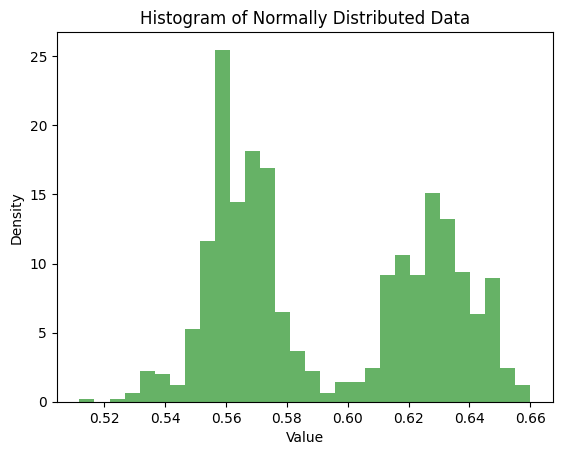

In [163]:
plt.hist(y_proba, bins=30, density=True, alpha=0.6, color='g')
plt.title('Histogram of Normally Distributed Data')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

In [164]:
y_proba_55 = (y_proba > 0.55).astype(int)
y_proba_55

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [165]:
df_unseen_feats.set_index('Date', inplace=True) 
df_unseen_feats.sort_index(inplace=True)

In [166]:
df_unseen_feats

,Open,High,Low,Prev Close,Last,Close,VWAP,Volume,Turnover,Trades,Symbol,1d_return,5d_ROC,10d_ROC,20d_ROC,momentum_ratio,SMA_10,SMA_20,SMA_50,EMA_12,EMA_26,ema_5,ema_20,close_to_SMA_10,close_to_SMA_20,close_to_SMA_50,ema_ratio,MACD,MACD_signal,MACD_histogram,RSI_14,williams_R_14,volatility_10,volatility_20,volatility_60,normalized_range,rolling_std_5,rolling_std_20,volatility_ratio,ATR_14,true_range,atr_14,bollinger_upper,bollinger_lower,bollinger_position,sharpe_20,volume_SMA_20,volume_SMA_10,volume_SMA_5,volume_ratio,vol_ma_5,vol_ma_20,vol_ratio,vwap_ratio,OBV,volume_return_corr_20,candle_body,upper_shadow,lower_shadow,bullish_engulfing,day_of_week,month,day_of_month,is_month_start,is_month_end,is_quarter_end,dow_0,dow_1,dow_2,dow_3,dow_4,dow_5,dow_6,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,1d_return_lag_1,1d_return_lag_2,1d_return_lag_3,1d_return_lag_5,volume_ratio_lag_1,volume_ratio_lag_2,volume_ratio_lag_5,RSI_14_lag_1,RSI_14_lag_3,RSI_14_lag_5,normalized_range_lag_1,normalized_range_lag_3,vol_ratio_lag_1,vol_ratio_lag_2,vol_ratio_lag_3,MACD_lag_1,MACD_lag_2,bollinger_position_lag_1,bollinger_position_lag_2,vwap_ratio_lag_1,vwap_ratio_lag_2,vwap_ratio_lag_3,ema_ratio_lag_1,ema_ratio_lag_2,ema_ratio_lag_3,normalized_range_rolling_mean_5,normalized_range_rolling_std_5,normalized_range_rolling_max_5,normalized_range_rolling_min_5,normalized_range_rolling_trend_5,normalized_range_rolling_mean_10,normalized_range_rolling_std_10,normalized_range_rolling_max_10,normalized_range_rolling_min_10,normalized_range_rolling_trend_10,normalized_range_rolling_mean_20,normalized_range_rolling_std_20,normalized_range_rolling_max_20,normalized_range_rolling_min_20,normalized_range_rolling_trend_20,bollinger_position_rolling_mean_5,bollinger_position_rolling_std_5,bollinger_position_rolling_max_5,bollinger_position_rolling_min_5,bollinger_position_rolling_trend_5,bollinger_position_rolling_mean_10,bollinger_position_rolling_std_10,bollinger_position_rolling_max_10,bollinger_position_rolling_min_10,bollinger_position_rolling_trend_10,bollinger_position_rolling_mean_20,bollinger_position_rolling_std_20,bollinger_position_rolling_max_20,bollinger_position_rolling_min_20,bollinger_position_rolling_trend_20,volume_ratio_rolling_mean_5,volume_ratio_rolling_std_5,volume_ratio_rolling_max_5,volume_ratio_rolling_min_5,volume_ratio_rolling_trend_5,volume_ratio_rolling_mean_10,volume_ratio_rolling_std_10,volume_ratio_rolling_max_10,volume_ratio_rolling_min_10,volume_ratio_rolling_trend_10,volume_ratio_rolling_mean_20,volume_ratio_rolling_std_20,volume_ratio_rolling_max_20,volume_ratio_rolling_min_20,volume_ratio_rolling_trend_20,1d_return_rolling_mean_5,1d_return_rolling_std_5,1d_return_rolling_max_5,1d_return_rolling_min_5,1d_return_rolling_trend_5,1d_return_rolling_mean_10,1d_return_rolling_std_10,1d_return_rolling_max_10,1d_return_rolling_min_10,1d_return_rolling_trend_10,1d_return_rolling_mean_20,1d_return_rolling_std_20,1d_return_rolling_max_20,1d_return_rolling_min_20,1d_return_rolling_trend_20,vol_ratio_rolling_mean_5,vol_ratio_rolling_std_5,vol_ratio_rolling_max_5,vol_ratio_rolling_min_5,vol_ratio_rolling_trend_5,vol_ratio_rolling_mean_10,vol_ratio_rolling_std_10,vol_ratio_rolling_max_10,vol_ratio_rolling_min_10,vol_ratio_rolling_trend_10,vol_ratio_rolling_mean_20,vol_ratio_rolling_std_20,vol_ratio_rolling_max_20,vol_ratio_rolling_min_20,vol_ratio_rolling_trend_20,RSI_14_rolling_mean_5,RSI_14_rolling_std_5,RSI_14_rolling_max_5,RSI_14_rolling_min_5,RSI_14_rolling_trend_5,RSI_14_rolling_mean_10,RSI_14_rolling_std_10,RSI_14_rolling_max_10,RSI_14_rolling_min_10,RSI_14_rolling_trend_10,RSI_14_rolling_mean_20,RSI_14_rolling_std_20,RSI_14_rolling_max_20,RSI_14_rolling_min_20,RSI_14_rolling_trend_20,vwap_ratio_rolling_mean_5,vwap_ratio_rolling_std_5,vwap_ratio_rolling_max_5,vwap_ratio_rolling_min_5,vwap_ratio_rolling_trend_5,vwap_ratio_rolling_mean_10,vwap_ratio_rolling_std_10,vwap_ratio_rolling_

In [167]:
# 6. Apply Threshold
# Since data is noisy, 0.7 is too high. We use 0.55 or 0.60.
threshold = 0.6
y_pred = (y_proba > threshold).astype(int)

print(f"Prediction Stats: {pd.Series(y_pred).value_counts()}")

# Assign predictions back to dataframe for simulation
df_unseen_feats['pred'] = y_pred



Prediction Stats: 0    553
1    440
Name: count, dtype: int64


In [168]:
df_unseen_feats

,Open,High,Low,Prev Close,Last,Close,VWAP,Volume,Turnover,Trades,Symbol,1d_return,5d_ROC,10d_ROC,20d_ROC,momentum_ratio,SMA_10,SMA_20,SMA_50,EMA_12,EMA_26,ema_5,ema_20,close_to_SMA_10,close_to_SMA_20,close_to_SMA_50,ema_ratio,MACD,MACD_signal,MACD_histogram,RSI_14,williams_R_14,volatility_10,volatility_20,volatility_60,normalized_range,rolling_std_5,rolling_std_20,volatility_ratio,ATR_14,true_range,atr_14,bollinger_upper,bollinger_lower,bollinger_position,sharpe_20,volume_SMA_20,volume_SMA_10,volume_SMA_5,volume_ratio,vol_ma_5,vol_ma_20,vol_ratio,vwap_ratio,OBV,volume_return_corr_20,candle_body,upper_shadow,lower_shadow,bullish_engulfing,day_of_week,month,day_of_month,is_month_start,is_month_end,is_quarter_end,dow_0,dow_1,dow_2,dow_3,dow_4,dow_5,dow_6,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,1d_return_lag_1,1d_return_lag_2,1d_return_lag_3,1d_return_lag_5,volume_ratio_lag_1,volume_ratio_lag_2,volume_ratio_lag_5,RSI_14_lag_1,RSI_14_lag_3,RSI_14_lag_5,normalized_range_lag_1,normalized_range_lag_3,vol_ratio_lag_1,vol_ratio_lag_2,vol_ratio_lag_3,MACD_lag_1,MACD_lag_2,bollinger_position_lag_1,bollinger_position_lag_2,vwap_ratio_lag_1,vwap_ratio_lag_2,vwap_ratio_lag_3,ema_ratio_lag_1,ema_ratio_lag_2,ema_ratio_lag_3,normalized_range_rolling_mean_5,normalized_range_rolling_std_5,normalized_range_rolling_max_5,normalized_range_rolling_min_5,normalized_range_rolling_trend_5,normalized_range_rolling_mean_10,normalized_range_rolling_std_10,normalized_range_rolling_max_10,normalized_range_rolling_min_10,normalized_range_rolling_trend_10,normalized_range_rolling_mean_20,normalized_range_rolling_std_20,normalized_range_rolling_max_20,normalized_range_rolling_min_20,normalized_range_rolling_trend_20,bollinger_position_rolling_mean_5,bollinger_position_rolling_std_5,bollinger_position_rolling_max_5,bollinger_position_rolling_min_5,bollinger_position_rolling_trend_5,bollinger_position_rolling_mean_10,bollinger_position_rolling_std_10,bollinger_position_rolling_max_10,bollinger_position_rolling_min_10,bollinger_position_rolling_trend_10,bollinger_position_rolling_mean_20,bollinger_position_rolling_std_20,bollinger_position_rolling_max_20,bollinger_position_rolling_min_20,bollinger_position_rolling_trend_20,volume_ratio_rolling_mean_5,volume_ratio_rolling_std_5,volume_ratio_rolling_max_5,volume_ratio_rolling_min_5,volume_ratio_rolling_trend_5,volume_ratio_rolling_mean_10,volume_ratio_rolling_std_10,volume_ratio_rolling_max_10,volume_ratio_rolling_min_10,volume_ratio_rolling_trend_10,volume_ratio_rolling_mean_20,volume_ratio_rolling_std_20,volume_ratio_rolling_max_20,volume_ratio_rolling_min_20,volume_ratio_rolling_trend_20,1d_return_rolling_mean_5,1d_return_rolling_std_5,1d_return_rolling_max_5,1d_return_rolling_min_5,1d_return_rolling_trend_5,1d_return_rolling_mean_10,1d_return_rolling_std_10,1d_return_rolling_max_10,1d_return_rolling_min_10,1d_return_rolling_trend_10,1d_return_rolling_mean_20,1d_return_rolling_std_20,1d_return_rolling_max_20,1d_return_rolling_min_20,1d_return_rolling_trend_20,vol_ratio_rolling_mean_5,vol_ratio_rolling_std_5,vol_ratio_rolling_max_5,vol_ratio_rolling_min_5,vol_ratio_rolling_trend_5,vol_ratio_rolling_mean_10,vol_ratio_rolling_std_10,vol_ratio_rolling_max_10,vol_ratio_rolling_min_10,vol_ratio_rolling_trend_10,vol_ratio_rolling_mean_20,vol_ratio_rolling_std_20,vol_ratio_rolling_max_20,vol_ratio_rolling_min_20,vol_ratio_rolling_trend_20,RSI_14_rolling_mean_5,RSI_14_rolling_std_5,RSI_14_rolling_max_5,RSI_14_rolling_min_5,RSI_14_rolling_trend_5,RSI_14_rolling_mean_10,RSI_14_rolling_std_10,RSI_14_rolling_max_10,RSI_14_rolling_min_10,RSI_14_rolling_trend_10,RSI_14_rolling_mean_20,RSI_14_rolling_std_20,RSI_14_rolling_max_20,RSI_14_rolling_min_20,RSI_14_rolling_trend_20,vwap_ratio_rolling_mean_5,vwap_ratio_rolling_std_5,vwap_ratio_rolling_max_5,vwap_ratio_rolling_min_5,vwap_ratio_rolling_trend_5,vwap_ratio_rolling_mean_10,vwap_ratio_rolling_std_10,vwap_ratio_rolling_

In [261]:

# # Ensure raw price columns exist for simulation
# if 'raw_Close' not in df_unseen_feats.columns:
#     df_unseen_feats['raw_Close'] = df_unseen['Close']
# if 'raw_Low' not in df_unseen_feats.columns:
#     df_unseen_feats['raw_Low'] = df_unseen['Low']
# if 'raw_20d_fwd_return' not in df_unseen_feats.columns:
#     df_unseen_feats['raw_20d_fwd_return'] = 0.0 # Placeholder if missing

# 7. Run Simulation
print("\n--- Running Trading Simulation ---")
# 7. Run Simulation
print("\n--- Running BREAKTHROUGH Simulation ---")
result = simulate_trading_1(
    df_unseen_feats,
    predictions=y_pred,
    initial_demat=20000.0,
    base_risk_per_trade=0.04,   # Risk 2% of EQUITY per trade (Compounding)
    max_concurrent_trades=15,       # Focus capital on best 3 ideas
    atr_multiplier=1.5,
    cooldown_days=1
)
# 8. Output Results
print("\n--- Metrics ---")
for k, v in result['metrics'].items():
    print(f"{k}: {v}")

# 9. Plot
try:
    viz = plot_backtest(result, df_unseen_feats, figures_dir="./backtest_plots")
    print("\nPlots saved to ./backtest_plots")
    plt.show()
except Exception as e:
    print(f"Plotting error (check Strategy.ipynb): {e}")


--- Running Trading Simulation ---

--- Running BREAKTHROUGH Simulation ---

--- Metrics ---
initial_demat: 20000.0
final_demat: 39349.42618187773
num_trades: 46
wins: 44
losses: 2
win_rate: 0.9565217391304348
avg_win: 17294.916860368077
avg_loss: -9628.71487497284
median_win: 17225.85815166121
median_loss: -9628.71487497284
avg_return_pct: 0.952004500934532
total_winning: 760976.3418561955
total_losing: 19257.42974994568
profit_factor: 39.515986906733595
expectancy: 16124.32417622282
largest_single_trade_gain: 40689.64781084994
largest_single_trade_loss: -13847.493071274837
avg_holding_days: 19.869565217391305
median_holding_days: 19.5
SL_exit_rate: 0.45652173913043476
Time_exit_rate: 0.0
total_return: 0.9674713090938865
annualized_return: 0.18461681688122522
annualized_volatility: 0.22387397842867648
sharpe_ratio: 0.8246461610992538
max_drawdown: -0.15534979315550962
Plotting error (check Strategy.ipynb): 'price_col_used'


In [197]:
import pandas as pd
import sys

# Set display options to prevent truncation
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None) # Ensures full content within columns is shown


print("\n--- Metrics ---")
for k, v in result.items():
    print(f"{k}: {v}")
    # Optional: ensure everything goes to stdout immediately
    sys.stdout.flush()



--- Metrics ---
final_demat: 32380.7356383686
trade_log:      trade_id entry_date  exit_date  entry_price   exit_price          pnl  return_pct exit_reason  holding_days
0           1 2021-03-01 2021-03-17       692.90   688.492857   -29.307683   -0.006360          SL            11
1           2 2021-03-02 2021-03-17       720.50   688.492857  -217.226967   -0.044424          SL            10
2           3 2021-03-03 2021-03-17       729.85   688.492857  -271.320093   -0.056665          SL             9
3           4 2021-03-04 2021-03-17       752.45   688.492857  -415.222291   -0.084999          SL             8
4           5 2021-03-17 2021-04-06       688.25   760.635714    19.674837    0.105174          SL            12
5           6 2021-03-18 2021-04-06       679.65   760.635714   525.922797    0.119158          SL            11
6           7 2021-03-19 2021-04-06       686.25   760.635714   486.442494    0.108394          SL            10
7           8 2021-03-22 2021-04-06   

equity_curve_no_mtm: Date
2021-02-01             NaN
2021-02-02             NaN
2021-02-03             NaN
2021-02-04             NaN
2021-02-05             NaN
2021-02-08             NaN
2021-02-09             NaN
2021-02-10             NaN
2021-02-11             NaN
2021-02-12             NaN
2021-02-15             NaN
2021-02-16             NaN
2021-02-17             NaN
2021-02-18             NaN
2021-02-19             NaN
2021-02-22             NaN
2021-02-23             NaN
2021-02-24             NaN
2021-02-25             NaN
2021-02-26             NaN
2021-03-01             NaN
2021-03-02             NaN
2021-03-03             NaN
2021-03-04             NaN
2021-03-05             NaN
2021-03-08             NaN
2021-03-09             NaN
2021-03-10             NaN
2021-03-12             NaN
2021-03-15             NaN
2021-03-16             NaN
2021-03-17    19066.922966
2021-03-18    19066.922966
2021-03-19    19066.922966
2021-03-22    19066.922966
2021-03-23    19066.922966
20

<Figure size 1000x1200 with 0 Axes>

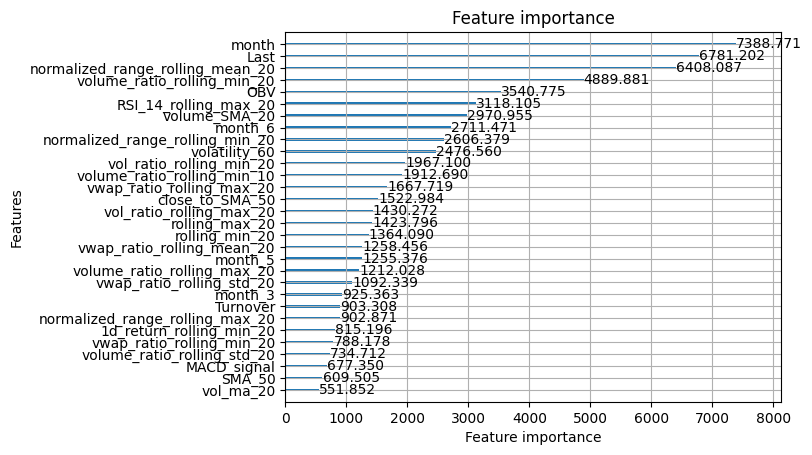

In [176]:
from lightgbm import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 12))
plot_importance(lgbm_model, max_num_features=30, importance_type='gain')
plt.show()
